In [56]:
import os, sys
import numpy as np
import pycolmap
import cv2
import struct
from pathlib import Path
from tqdm import tqdm_notebook as tqdm
import matplotlib.pyplot as plt
import utils.matrix
import time

In [57]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [29]:
sparse_dir = Path("output/0")  # COLMAP에서 생성된 데이터가 저장된 폴더
image_dir = Path("images_no_bg")  # 실제 이미지가 저장된 폴더

In [30]:
reconstruction = pycolmap.Reconstruction("output/0")
print(reconstruction)

Reconstruction(num_cameras=193, num_images=193, num_reg_images=193, num_points3D=7161)


In [31]:
# 카메라 정보 가져오기
cameras = reconstruction.cameras
camera = list(cameras.values())[0]  # 첫 번째 카메라 정보 사용

In [39]:
# COLMAP images.bin 파일 경로
images_bin_path = "output/0"

# images.bin 파일 로드
reconstruction = pycolmap.Reconstruction()
reconstruction.read(images_bin_path)

# 첫 번째 이미지 객체 확인 (구조 분석)
image_ids = list(reconstruction.images.keys())
first_image = reconstruction.images[image_ids[0]]

# Rotation3d 객체 확인
rotation_data = first_image.cam_from_world.rotation

# Rotation3d 객체가 어떤 속성을 가지고 있는지 확인
print(dir(rotation_data))

['__class__', '__copy__', '__deepcopy__', '__delattr__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__mul__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__str__', '__subclasshook__', '_pybind11_conduit_v1_', 'angle', 'angle_to', 'inverse', 'matrix', 'mergedict', 'norm', 'normalize', 'quat', 'summary', 'todict']


In [32]:
# Focal Length 및 해상도 가져오기
focal = camera.focal_length
H, W = camera.height, camera.width
print(f"Camera Info: Focal Length = {focal}, Image Size = ({W}, {H})")

# 2️⃣ 이미지 및 포즈 데이터 가져오기 (images.bin)
image_data = reconstruction.images
sorted_images = sorted(image_data.items(), key=lambda x: x[1].name)
# 3️⃣ 이미지 배열 및 카메라 포즈 배열 만들기
image_list = []
pose_list = []
print(f"Total images in COLMAP reconstruction: {len(image_data)}")


Camera Info: Focal Length = 803.3034878397515, Image Size = (720, 720)
Total images in COLMAP reconstruction: 193


In [48]:
# 2️⃣ 이미지 및 포즈 데이터 가져오기 (images.bin)
image_data = reconstruction.images
sorted_images = sorted(image_data.items(), key=lambda x: x[1].name)
print(f"Total images in COLMAP reconstruction: {len(image_data)}")

Total images in COLMAP reconstruction: 193


In [49]:
# 3️⃣ 이미지 배열 및 카메라 포즈 배열 만들기
image_list = []
pose_list = []

for img_id, image in sorted_images:
    img_path = image_dir / image.name
    img = cv2.imread(str(img_path))  # 이미지 로드
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # BGR → RGB 변환
    image_list.append(img)

    # COLMAP의 카메라 포즈 변환 (Rigid3d → 4x4 변환 행렬)
    pose = np.eye(4)  # 4x4 단위 행렬 생성

    # 🔹 Quaternion (w, x, y, z) → 3x3 회전 행렬 변환
    qvec = np.array(image.cam_from_world.rotation.quat)
    pose[:3, :3] = utils.matrix.qvec_to_rotmat(qvec)  # Quaternion을 3x3 회전 행렬로 변환

    # 🔹 Translation 벡터 변환 (COLMAP은 camera-to-world 변환이므로 부호 반전)
    pose[:3, 3] = -np.array(image.cam_from_world.translation)

    # 🔹 COLMAP 좌표계를 OpenGL 좌표계로 변환 (NeRF 호환)
    pose = np.diag([1, -1, -1, 1]) @ pose  # YZ 축 반전 (COLMAP → OpenGL)

    print(f"Image {img_id} pose matrix:\n{pose}\n")  # 변환된 행렬 출력
    pose_list.append(pose)

Image 1 pose matrix:
[[-0.98773642  0.06164084 -0.14344747  1.01444728]
 [ 0.03764048  0.98567942  0.1643754  -1.07931339]
 [ 0.15152546  0.15696014 -0.97591165  2.96656552]
 [ 0.          0.          0.          1.        ]]

Image 5 pose matrix:
[[-0.99387441  0.05025463 -0.09842827  1.07994597]
 [ 0.03825207  0.99200739  0.12024191 -1.1126834 ]
 [ 0.10368428  0.11574027 -0.98785311  3.11026362]
 [ 0.          0.          0.          1.        ]]

Image 4 pose matrix:
[[-0.99793839  0.03944291 -0.05062839  1.09989953]
 [ 0.03580488  0.9968437   0.07085658 -1.13510671]
 [ 0.05326338  0.06889776 -0.99620084  3.27334156]
 [ 0.          0.          0.          1.        ]]

Image 2 pose matrix:
[[-0.99960911  0.0252997   0.01189792  1.08065886]
 [ 0.02536368  0.99966446  0.00525754 -1.17623374]
 [-0.01176091  0.00555726 -0.9999154   3.42362906]
 [ 0.          0.          0.          1.        ]]

Image 3 pose matrix:
[[-0.99711388  0.01190225  0.07498161  1.04457082]
 [ 0.0074635   0.998

In [50]:
# 이미지 리스트 → NumPy 배열 변환 (dtype 명확히 지정)
images = np.stack(image_list, axis=0)  # np.array() 대신 np.stack() 사용
poses = np.stack(pose_list, axis=0)    # 포즈도 같은 방식으로 변환

print(f"Images Shape: {images.shape}, Poses Shape: {poses.shape}")

Images Shape: (193, 720, 720, 3), Poses Shape: (193, 4, 4)


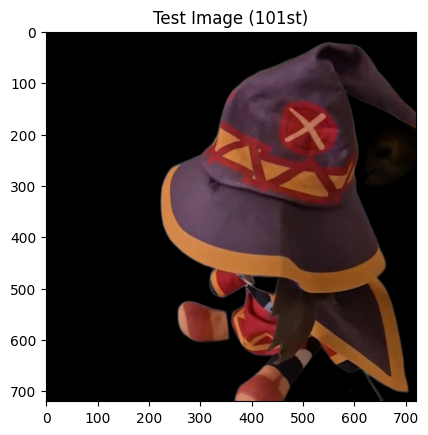

In [51]:
# 4️⃣ 특정 테스트 이미지 및 포즈 선택 (101번째 이미지)
# 🔹 테스트 이미지 및 포즈 선택 (101번째 이미지 사용 가능)
testimg, testpose = images[101], poses[101]

# 🔹 NeRF 학습용으로 사용할 이미지 개수 설정 (100개로 제한하지 않음)
train_images = images  # 193개 이미지 전부 사용
train_poses = poses  # 193개 포즈 전부 사용

# 🔹 테스트 이미지 출력
plt.imshow(testimg)
plt.title("Test Image (101st)")
plt.show()

In [77]:
# 위치 인코딩 함수 (Positional Encoding)
# class PositionalEncoding(nn.Module):
#     def __init__(self, L_embed=6):
#         super(PositionalEncoding, self).__init__()
#         self.L_embed = L_embed

#     def forward(self, x):
#         if self.L_embed == 0:
#             return x  # 위치 인코딩 없이 원본 값 사용
#         rets = [x]
#         for i in range(self.L_embed):
#             for fn in [torch.sin, torch.cos]:
#                 rets.append(fn(2.0 ** i * x))
#         encoded_x = torch.cat(rets, dim=-1)

#         # 🔥 디버깅: 위치 인코딩 차원 확인
#         print(f"🔥 Debug: Positional Encoding Output Shape = {encoded_x.shape}")
#         return encoded_x

# ✅ 메모리 절약을 위해 float16 사용
class PositionalEncoding(nn.Module):
    def __init__(self, L_embed=6):
        super(PositionalEncoding, self).__init__()
        self.L_embed = L_embed

    def forward(self, x):
        with torch.no_grad():  # ✅ 연산 기록 X (메모리 절약)
            if self.L_embed == 0:
                return x
            rets = [x]
            for i in range(self.L_embed):
                for fn in [torch.sin, torch.cos]:
                    rets.append(fn(2.0 ** i * x).to(torch.float16))  # ✅ float16 변환 (메모리 절약)
            return torch.cat(rets, dim=-1).to(torch.float16)  # ✅ float16 변환 후 반환



# 🔹 L_embed 값에 따라 위치 인코딩 활성화 여부 결정
L_embed = 6  # 위치 인코딩 활성화
# L_embed = 0  # 위치 인코딩 비활성화

embed_fn = PositionalEncoding(L_embed)  # PyTorch에서 사용

dummy_input = torch.randn(1, 3)  # 예제 입력
encoded = embed_fn(dummy_input)
print(f"🔥 Debug: Encoded shape = {encoded.shape}")  # ✅ 차원 확인

# NeRF MLP 모델
class NeRFModel(nn.Module):
    def __init__(self, D=8, W=256, L_embed=6):
        super(NeRFModel, self).__init__()
        self.L_embed = L_embed
        self.embed_fn = PositionalEncoding(L_embed)

        # ✅ 입력 차원을 위치 인코딩 크기에 맞게 설정
        self.input_dim = 3 + 3 * 2 * L_embed  # 3D 좌표 + 위치 인코딩 차원
        print(f"🔥 Debug: Model input_dim = {self.input_dim}")  # ✅ 차원 확인

        layers = []
        for i in range(D):
            if i == 0:
                layers.append(nn.Linear(self.input_dim, W))  # ✅ 첫 번째 레이어 input_dim 확인
            else:
                layers.append(nn.Linear(W, W))
            layers.append(nn.ReLU())

            if i % 4 == 0 and i > 0:  # Residual Connection
                layers.append(nn.Linear(W, W))  # ✅ Residual 부분도 수정

        layers.append(nn.Linear(W, 4))  # 마지막 출력: RGB(3) + sigma(1)
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        # ✅ 위치 인코딩 적용 후 차원 확인
        x = self.embed_fn(x)

        # 🔥 Debug: 최종 모델 입력 차원 확인
        if x.shape[-1] != self.input_dim:
            raise ValueError(f"❌ Mismatch: Model expects {self.input_dim} but got {x.shape[-1]}")

        return self.model(x)



def get_rays(H, W, focal, c2w):
    """
    H, W: 이미지 해상도
    focal: 초점 거리
    c2w: 카메라 좌표계 변환 행렬 (4x4)
    """
    device = c2w.device  # ✅ c2w의 디바이스(GPU/CPU) 가져오기

    # ✅ CPU가 아닌 c2w의 디바이스에서 생성하도록 수정
    i, j = torch.meshgrid(
        torch.arange(W, dtype=torch.float32, device=device),
        torch.arange(H, dtype=torch.float32, device=device),
        indexing='xy'
    )
    
    # ✅ c2w의 디바이스에서 연산하도록 변경
    dirs = torch.stack([(i - W * 0.5) / focal, -(j - H * 0.5) / focal, -torch.ones_like(i, device=device)], dim=-1)

    # ✅ c2w가 GPU에 있을 경우 모든 연산이 GPU에서 수행됨
    rays_d = torch.sum(dirs[..., None, :] * c2w[:3, :3], dim=-1)
    rays_o = c2w[:3, -1].expand(rays_d.shape)

    return rays_o, rays_d



# NeRF 렌더링 함수
def render_rays(network_fn, rays_o, rays_d, near, far, N_samples, rand=False):
    device = rays_o.device  # ✅ 모든 텐서의 디바이스를 맞추기 위해 사용

    def batchify(fn, chunk=1024*32):
        return lambda inputs: torch.cat([fn(inputs[i:i+chunk]) for i in range(0, inputs.shape[0], chunk)], dim=0)

    # ✅ `z_vals`를 `device`에 맞게 생성
    z_vals = torch.linspace(near, far, N_samples, device=device)
    
    if rand:
        z_vals += torch.rand_like(z_vals) * (far - near) / N_samples

    # 3D 포인트 계산
    pts = rays_o[..., None, :] + rays_d[..., None, :] * z_vals[..., :, None]

    # ✅ pts_flat이 예상한 차원을 가지는지 확인
    pts_flat = pts.view(-1, 3)
    print(f"🔥 Debug: pts_flat.shape = {pts_flat.shape}")  # ✅ 차원 확인
    pts_flat = network_fn.embed_fn(pts_flat)  # 위치 인코딩 적용
    print(f"🔥 Debug: Encoded pts_flat.shape = {pts_flat.shape}")  # ✅ 차원 확인

    # 🔥 Debug: NeRFModel input_dim과 일치하는지 확인
    if pts_flat.shape[-1] != network_fn.input_dim:
        raise ValueError(f"❌ Shape mismatch: Expected {network_fn.input_dim}, but got {pts_flat.shape[-1]}")

    raw = batchify(network_fn)(pts_flat)
    raw = raw.view(list(pts.shape[:-1]) + [4])

    # RGB 및 밀도(sigma)
    sigma_a = F.relu(raw[..., 3])
    rgb = torch.sigmoid(raw[..., :3])

    # 볼륨 렌더링
    dists = torch.cat([z_vals[..., 1:] - z_vals[..., :-1], torch.full_like(z_vals[..., :1], 1e10)], dim=-1)
    alpha = 1.0 - torch.exp(-sigma_a * dists)
    weights = alpha * torch.cumprod(torch.cat([torch.ones_like(alpha[..., :1]), 1.0 - alpha + 1e-10], dim=-1), dim=-1)[..., :-1]

    # 최종 출력값
    rgb_map = torch.sum(weights[..., None] * rgb, dim=-2)
    depth_map = torch.sum(weights * z_vals, dim=-1)
    acc_map = torch.sum(weights, dim=-1)

    return rgb_map, depth_map, acc_map



🔥 Debug: Encoded shape = torch.Size([1, 39])


In [78]:
# 모델 초기화
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
model = NeRFModel(D=8, W=256, L_embed=6).to(device)
optimizer = optim.Adam(model.parameters(), lr=5e-4)

# 🔹 Mixed Precision 사용
scaler = torch.cuda.amp.GradScaler()

def batchify(fn, chunk=4096):  # 🔹 chunk 크기를 줄여 메모리 사용량 절감
    return lambda inputs: torch.cat([fn(inputs[i:i + chunk]) for i in range(0, inputs.shape[0], chunk)], dim=0)

# 🔹 GPU 메모리 부족 시 자동으로 CPU 사용
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

try:
    model = NeRFModel(D=8, W=256, L_embed=6).to(device)
except RuntimeError:
    print("CUDA Out of Memory! Switching to CPU...")
    device = "cpu"
    model = NeRFModel(D=8, W=256, L_embed=6).to(device)

# 학습 파라미터
N_samples = 16
N_iters = 1000
psnrs = []
iternums = []
i_plot = 25

# 학습 시작
t = time.time()
torch.cuda.empty_cache()  # GPU 메모리 캐시 비우기

for i in range(N_iters + 1):
    img_i = np.random.randint(images.shape[0])  # 랜덤 이미지 선택
    target = torch.tensor(images[img_i], dtype=torch.float32, device=device)  # ✅ device 지정
    pose = torch.tensor(poses[img_i], dtype=torch.float32, device=device)  # ✅ device 지정


    # 🔹 GPU 메모리 부족 방지
    torch.cuda.empty_cache()
    
    # ✅ 광선 생성 (이제 모든 텐서가 동일한 device에 존재)
    rays_o, rays_d = get_rays(H, W, focal, pose)

    # 모델 학습
    optimizer.zero_grad()
    with torch.cuda.amp.autocast():  # 🔹 Mixed Precision 적용
        rgb, depth, acc = render_rays(model, rays_o, rays_d, near=2.0, far=6.0, N_samples=N_samples, rand=True)
        loss = F.mse_loss(rgb, target)
    
    # rgb, depth, acc = render_rays(model, rays_o, rays_d, near=2.0, far=6.0, N_samples=N_samples, rand=True)

    # loss = F.mse_loss(rgb, target)
    # loss.backward()
    # torch.cuda.empty_cache()  # GPU 메모리 캐시 비우기
    # optimizer.step()
    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()

    # 로그 출력 및 평가
    if i % i_plot == 0:
        print(i, (time.time() - t) / i_plot, 'secs per iter')
        t = time.time()

        # 테스트용 광선 생성
        # testpose_tensor = torch.tensor(testpose, dtype=torch.float32, device=device)  # ✅ device 지정
        # rays_o, rays_d = get_rays(H, W, focal, testpose_tensor)
        rays_o, rays_d = get_rays(H, W, focal, testpose)
        
        with torch.no_grad():
            rgb, depth, acc = render_rays(model, rays_o, rays_d, near=2.0, far=6.0, N_samples=N_samples)

        loss = F.mse_loss(rgb, torch.tensor(testimg, dtype=torch.float32, device=device))
        psnr = -10. * torch.log10(loss)

        psnrs.append(psnr.item())
        iternums.append(i)

        # 결과 시각화
        plt.figure(figsize=(10, 4))
        plt.subplot(121)
        plt.imshow(rgb.cpu().numpy())  # GPU → CPU 변환 후 시각화
        plt.title(f'Iteration: {i}')
        plt.subplot(122)
        plt.plot(iternums, psnrs)
        plt.title('PSNR')
        plt.show()

print('Done')

Device: cuda
🔥 Debug: Model input_dim = 39
Using device: cuda
🔥 Debug: Model input_dim = 39
🔥 Debug: pts_flat.shape = torch.Size([8294400, 3])


C:\Users\Administrator\AppData\Local\Temp\ipykernel_11444\1013226924.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_11444\1013226924.py:49: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():  # 🔹 Mixed Precision 적용


OutOfMemoryError: CUDA out of memory. Tried to allocate 96.00 MiB. GPU 0 has a total capacity of 6.00 GiB of which 0 bytes is free. Of the allocated memory 20.50 GiB is allocated by PyTorch, and 122.40 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)